In [1]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
import matplotlib

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
fontsize=9
plt.rcParams['font.size'] = fontsize


def SIA_diffusion1D(Lx,J,Dright,Dleft,H0,tf,b):
    ##################################################################
    # Matlab code written by Ed Bueler, Professor of Mathematics (Applied);
    # Dept. of Mathematics & Statistics; University of Alaska Fairbanks.
    # 
    # The code accompanies the course notes on:
    # "Numerical modeling of glaciers, ice sheets, and ice shelves"
    # International Summer School in Glaciology McCarthy Alaska, June 2016
    # 
    # Code downloaded from:
    # https://github.com/bueler/karthaus/tree/master/mfiles
    # 
    # Converted from 2d shallow ice approximation to 1d, and 
    # from Matlab to python: Eli Tziperman
    ##################################################################
    # DIFFUSION  Adaptive explicit method for diffusion equation
    #   H_t = F + div (D grad (H + b))
    # on a domain (-Lx,Lx) with initial condition H0 and
    # functions F(x), D(x), b(x).  The boundary condition is that
    # the T values at the edge of the domain (i.e. H(1,.), H(J+1,.), H(.,1),
    # H(.,K+1)) are all held fixed at their initial values supplied in H0.
    # That is, the boundary condition is a Dirichlet condition from the
    # initial values.
    # Usage:
    #   H = diffusion(Lx,J,Dright,Dleft,H0,tf,F)
    # where
    #   H     = approximate solution at tf
    #   Lx,Ly = half-widths of rectangular domain
    #   J,K   = number of subintervals in x,y directions, resp.
    #   D*    = (J-1) arrays with diffusivities for "staggered" grid
    #   H0    = (J+1) array with initial values on regular grid
    #   tf    = final time
    #   b     = (J+1) array with offset before gradient
    # Note: There is no error checking on sizes of D*, H0, F, b arrays.
    # Note: There is no text output.  Restore commented 'fprintf' if desired.
    # Note: The input diffusivities could be time-dependent, but they are
    #   time-independent in this simplified implementation.  Call-back could
    #   implement time-dependent diffusivity D(t,x).
    # Example: Compare this result to HEATADAPT:
    #   >> J = 50;  K = 50;  D = ones(J-1);
    #   >> [x,y] = ndgrid(-1:2/J:1);
    #   >> H0 = exp(-30*(x.*x));
    #   >> H = diffusion(1.0,J,D,D,H0,0.05);
    #   >> plot(x,H)
    # Called by: SIAFLAT, SIAGENERAL.

    # spatial grid and initial condition
    dx = 2 * Lx / J;
    x = np.arange(-Lx,Lx+dx,dx); # (J+1)  grid in x dimension
    H = 1.0*H0;

    #print('  doing explicit steps adaptively on 0.0 < t < ',tf)
    t = 0.0;    count = 0;
    while t < tf:
        # stability condition gives time-step restriction
        maxD = np.maximum(np.max(Dleft), np.max(Dright));
        #maxD = np.max(maxD);  # scalar maximum of D
        if maxD <= 0.0:  # e.g. happens with zero thickness ice sheets
            dt = tf - t;
        else:
            dt0 = 0.25 * (dx)**2 / maxD;
            dt = np.minimum(dt0, tf - t);  # do not go past tf

        mu_x = dt / (dx*dx);
        Hb = H + b;
        H[1:J] = H[1:J] + \
           mu_x * Dright * ( Hb[2:J+1] - Hb[1:J]   ) - \
           mu_x * Dleft  * ( Hb[1:J]   - Hb[0:J-1] );
        F=SMB(b+H);
        H = H + F * dt;
        t = t + dt;    count = count + 1;

    dtav = tf / count;
    return H,dtav


def SIA_siageneral1D(Lx,J,H0,deltat,tf,b,A):
    ##################################################################
    # Matlab code written by Ed Bueler, Professor of Mathematics (Applied);
    # Dept. of Mathematics & Statistics; University of Alaska Fairbanks.
    # 
    # The code accompanies the course notes on:
    # "Numerical modeling of glaciers, ice sheets, and ice shelves"
    # International Summer School in Glaciology McCarthy Alaska, June 2016
    # 
    # Code downloaded from:
    # https://github.com/bueler/karthaus/tree/master/mfiles
    # 
    # Converted from 2d shallow ice approximation to 1d, and 
    # from Matlab to python: Eli Tziperman
    ##################################################################
    # SIAGENERAL  Numerical solution of isothermal n=3 SIA
    #   H_t = SMB + div (D grad (H + b))
    # where  H = (ice thickness), the ice surface elevation is h = H + b,
    # SMB = (surface mass balance, function), and D is the diffusivity.  We allow
    # with 1d bed elevation b(x), general surface mass balance SMB(x),
    # and nonnegative thickness rule.  Any floating ice is immediately calved.
    # Compare SIAFLAT.
    # Usage:
    #   [H,h,dtlist] = siageneral(Lx,J,H0,deltat,tf,b,A)
    # where
    #   H      = numerical approx of thickness at final time
    #   h      = numerical approx of surface elevation at final time
    #   dtlist = list of time steps used adaptively in diffusion.m
    #   Lx,Ly  = half lengths of rectangle in x,y directions
    #   J,K    = number of subintervals in x,y directions
    #   H0     = initial thickness, a (J+1) array
    #   deltat = major time step
    #   tf     = final time
    #   b      = bed elevation, a (J+1) array
    #   SMB      = surface mass balance, a (J+1) array calculated by SMB function
    #   A      = ice softness
    # Calls: DIFFUSION, which does adaptive explicit time-stepping within the
    # major time step deltat.
    # Example: See ANT.

    # constants
    g = 9.81;    rho = 910.0;    rhow = 1028.0;
    Gamma  = 2 * A * (rho * g)**3 / 5; # see Bueler et al (2005)
    f = rho / rhow;                   # fraction of floating ice below surface
    
    dx = 2 * Lx / J;
    N = int(np.ceil(tf / deltat));   deltat = tf / N;
    j  = np.arange(1,J);   # interior indices
    ej = np.arange(2,J+1);
    wj = np.arange(0,J-1); # east,west

    t = 0;   dtlist = [];
    H = 1.0*H0;
    for n in range(1,N):
        # staggered grid thicknesses
        Hrt  = 0.5 * ( H[ej] + H[j] ); # right
        Hlt  = 0.5 * ( H[j] + H[wj] ); # left
        h = np.maximum(H*0.0,H + b); # update surface; uses sea level of z=0
        # staggered grid value of |grad h|^2 = "alpha^2"
        a2rt = (h[ej] - h[j])**2 / dx**2;
        a2lt = (h[j] - h[wj])**2 / dx**2;     
        # Mahaffy's staggered grid diffusivity: D = Gamma H^{n+2} |grad h|^{n-1}
        Drt  = Gamma * Hrt**5 * a2rt;
        Dlt  = Gamma * Hlt**5 * a2lt;
        # call *adaptive* diffusion() to time step H
        H,dtadapt = SIA_diffusion1D(Lx,J,Drt,Dlt,H,deltat,b);
        # enforce nonnegative thickness (H->0 can occur where SMB<0):
        H = np.maximum(H,0.0); 
        calvehere = (b < - f * H);  # floating
        H[calvehere] = 0.0;   # calving occurs anywhere the ice is floating
        t = t + deltat;
        dtlist.append(dtadapt);

    h = np.maximum(0.0,H + b); # finalize surface
    return H,h,dtlist


def SMB(s):
    # surface mass balance:
    # input: ice surface height array: s=b+H
    # output: SMB array at height of ice surface
    F=np.minimum(2.0,0.01*(s-ELA));
    F=np.maximum(-8.0,F);
    return F

print("done.")

done.


In [6]:
# define parameters and initial conditions:
Lx=15000; # length of domain
J=5000; # number of grid points
deltat=0.0002; # initial time step, in years
tf=deltat*10000; # length of each sub-run
N=120  # number of sub-runs
A=1.e-18; # ice softness

# equilibrium line altitude for two scenarios:
ELA_a=5000 
ELA_b=5500

# topography:
b=6000*np.exp(-(np.asarray(np.arange(0,J+1))-J/2)**2/(J/3)**2);

# initial conditions:
H0=np.zeros((J+1));
for j in range(0,J):
    H0[j]=H0[j]+100*np.cos( np.pi*(j-J/2.0)/(J/3) );
H0[H0<10]=0;
H0[b<3000]=0;

print("done.")

done.


In [14]:
###############
# Main program:
###############

print("running model, saving state every %g years, total run is for %g years" \
      % (tf, N*tf))

# calculate thickness before warming:
ELA=ELA_a
H_before=1.0*H0
for i in range(0,N):
    H_before,h,dtlist = SIA_siageneral1D(Lx,J,H_before,deltat,tf,b,A);

# calc thickness after warming: start from final solution for H of prev case.
ELA=ELA_b
H_after=H_before
H_all_times=np.zeros((J+1,N))
time=np.zeros(N)
for i in range(0,N):
    H_after,h,dtlist = SIA_siageneral1D(Lx,J,H_after,deltat,tf,b,A);
    H_all_times[:,i]=H_after;
    time[i]=i*tf


# save output to allow re-plotting without running the model:
np.save("Output/H_before.npy",H_before)
np.save("Output/H_after.npy",H_after)
np.save("Output/H_all_times.npy",H_all_times)
np.save("Output/ELA_a.npy",ELA_a)
np.save("Output/ELA_b.npy",ELA_b)
np.save("Output/Lx.npy",Lx)
np.save("Output/time.npy",time)

print("done.")

In [7]:
H_before=np.load("Output/H_before.npy",)
H_after=np.load("Output/H_after.npy")
H_all_times=np.load("Output/H_all_times.npy")
ELA_a=np.load("Output/ELA_a.npy")
ELA_b=np.load("Output/ELA_b.npy")
Lx=np.load("Output/Lx.npy")

print("done.")

done.


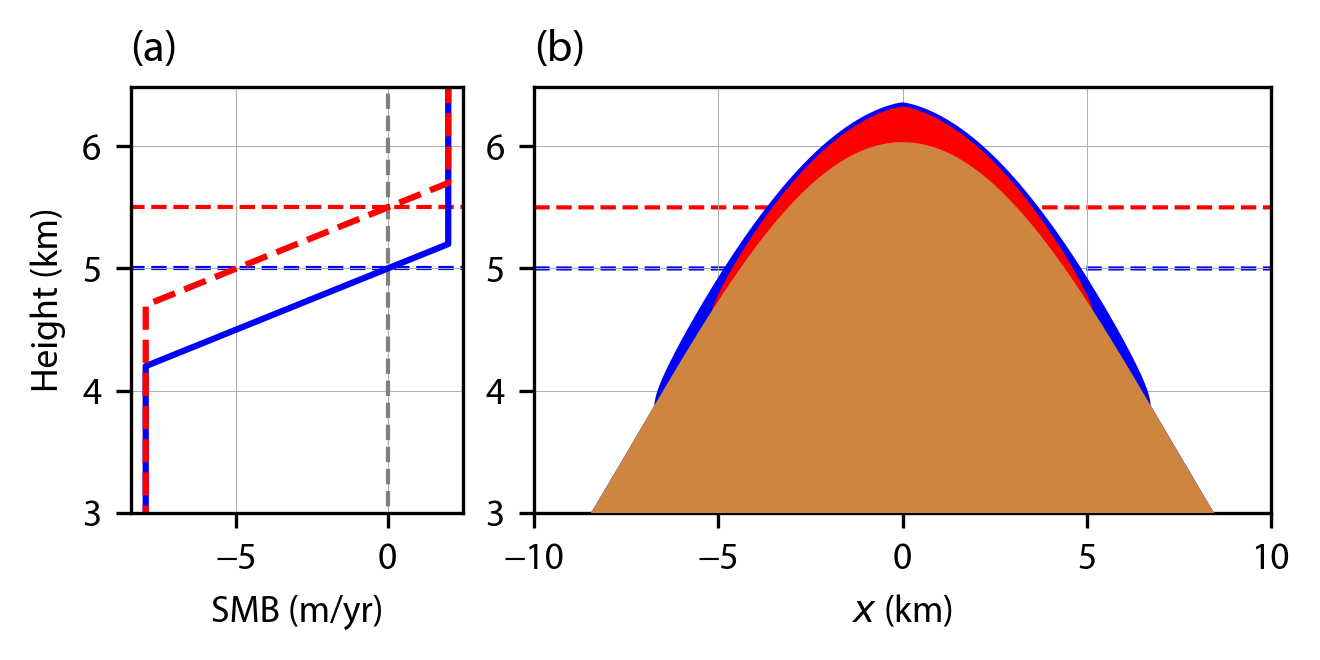

In [8]:
# -------------------------------------------------------------
# plot two SMBs as function of height, and the two
# corresponding steady solutions
# -------------------------------------------------------------

fig=plt.figure(figsize=(4.2,2.0),dpi=300); plt.clf

# left panel: SMB:
plt.subplot2grid((1,3),(0,0),colspan=1)
ax=plt.gca()
plt.title('(a)',loc="left")
Z=np.asarray(np.arange(0,6500,10));
ELA=ELA_a
SMB_profile=SMB(Z)
plt.plot(0*SMB_profile,Z/1000,'grey',lw=1,ls='--')
plt.plot(SMB_profile,Z/1000,'b')
ELA=ELA_b
SMB_profile=SMB(Z)
plt.plot(SMB_profile,Z/1000,'--r')
plt.grid(lw=0.25)
plt.xlabel('SMB (m/yr)')
plt.ylabel('Height (km)')
plt.ylim(3,Z[-1]/1000)
# plot lines at ELAs:
s=np.arange(-10,10,1)
plt.plot(s,0*s+ELA_a/1000,'b',lw=1,ls='--',alpha=1.0,zorder=-10)
plt.plot(s,0*s+ELA_b/1000,'r',lw=1,ls='--',alpha=1.0,zorder=-10)
plt.xlim(-8.5,2.5)


dx = 2 * Lx / J;
x = np.arange(-Lx,Lx+dx,dx); # (J+1)  grid in x dimension
x=x/1000;

# right panel: ice thickness over topography:
plt.subplot2grid((1,3),(0,1),colspan=2)
ax=plt.gca()
plt.title('(b)',loc="left")
#plt.plot(x,(b+H_before)/1000,'b',lw=1)
#plt.plot(x,b/1000,color='grey',lw=1)
plt.xlabel('$x$ (km)')
plt.xlim(-10,10)
plt.ylim(3,Z[-1]/1000)
plt.grid(lw=0.25,zorder=-100)
plt.plot(x,0*b+ELA_a/1000,'b',lw=1,ls='--',alpha=1.0,zorder=-10)
plt.plot(x,0*b+ELA_b/1000,'r',lw=1,ls='--',alpha=1.0,zorder=-10)

plt.plot(x,(b+H_before)/1000,'b',lw=2);
plt.fill_between(x,b/1000,(b+H_before)/1000,color='b',lw=0,alpha=1,zorder=5);
plt.plot(x,b/1000,color='k',lw=1)

plt.fill_between(x,b/1000,(b+H_after)/1000,color='r',lw=0,alpha=1,zorder=10);
plt.fill_between(x,b/1000,0*b,color='peru',lw=2,alpha=1,zorder=20);

plt.tight_layout(pad=0,w_pad=0.6)
fig.savefig("Output/mountain-glaciers-SIA-two-steady-states.pdf")

NameError: name 'time' is not defined

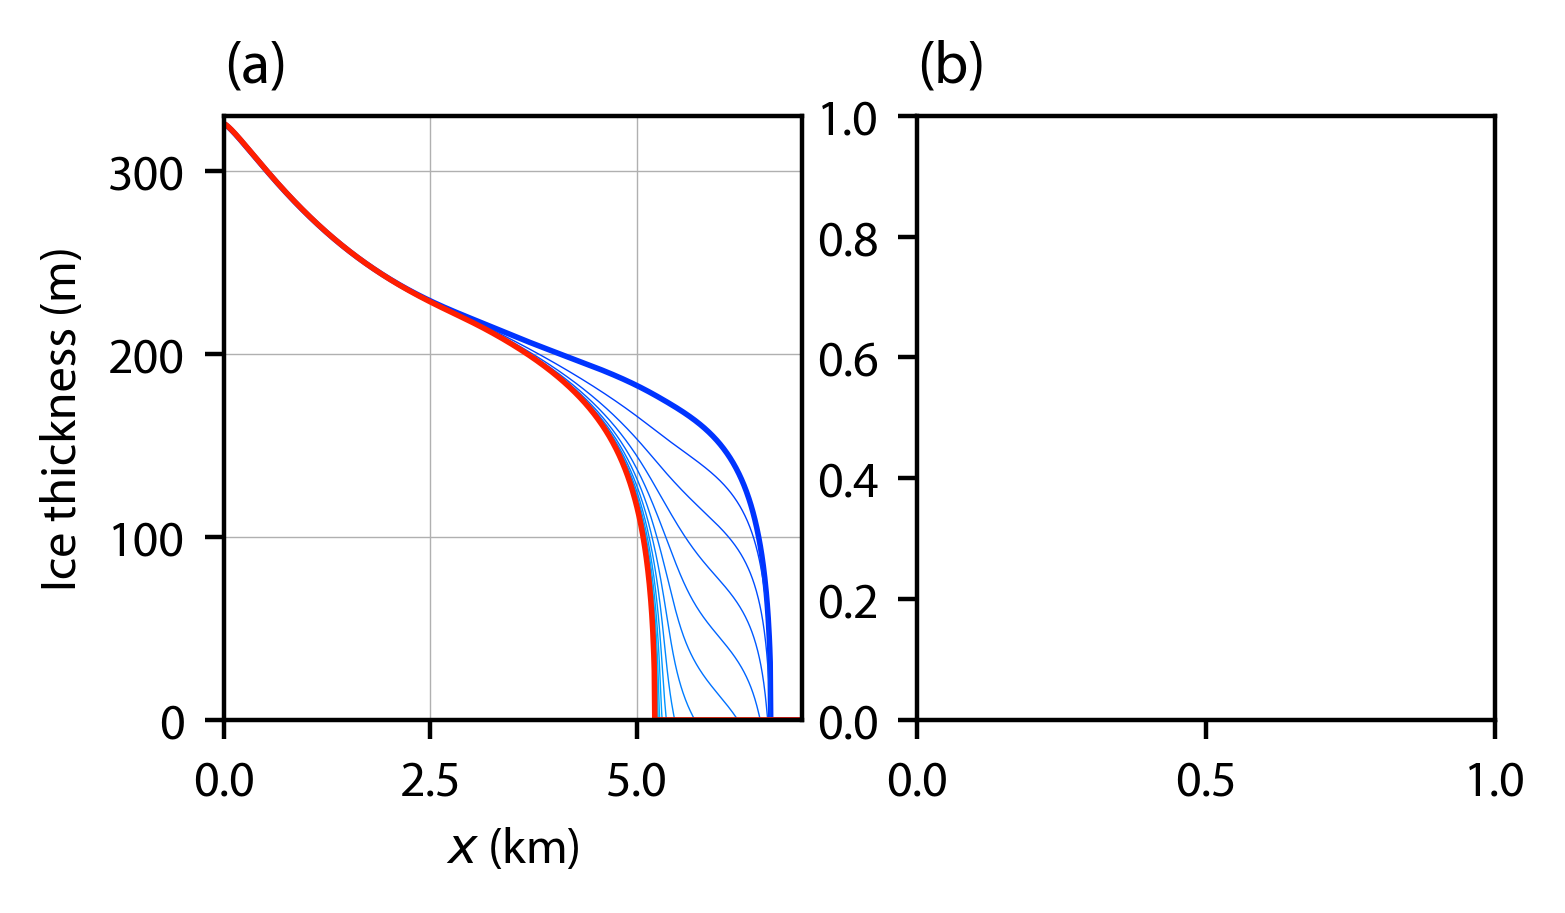

In [9]:
# ------------------------------------------------
# plot temporal evolution from blue to red states:
# ------------------------------------------------
fig=plt.figure(figsize=(4.1,2),dpi=400); plt.clf

# left panel: H(x) at different times:
myjet=plt.cm.jet(np.linspace(0,1,N+50));

plt.subplot(1,2,1)
ax=plt.gca()
plt.title('(a)',loc="left")
for i in range(0,N,2):
    if i==0 or i==N-2:
        lw=1
    else:
        lw=0.25
    plt.plot(x,H_all_times[:,i],color=myjet[i+30,:],lw=lw)
plt.xlim(0,7)
plt.ylim(0,330)
plt.grid(lw=0.25)
plt.xlabel('$x$ (km)')
plt.ylabel('Ice thickness (m)')

# right panel: Glacier length as function of time:
plt.subplot(1,2,2)
ax=plt.gca()
plt.title('(b)',loc="left")
glacier_length_all_times=np.zeros(N)
for i in range(N):
    glacier_length_all_times[i]=len(H_all_times[H_all_times[:,i]>0,i])*dx/2

plt.plot(time,glacier_length_all_times/1000,lw=2,color='b')
plt.xlim(0,80)
plt.grid(lw=0.25)
plt.ylabel('Glacier extent (km)')
plt.xlabel('Time (years')

plt.tight_layout(pad=0,w_pad=0.6)
fig.savefig("Output/mountain-glaciers-SIA-transition.pdf");